In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, accuracy_score

In [5]:
df = pd.read_csv('/content/drive/MyDrive/AIML_LAB/Exp9&10/archive/mitbih_train.csv')

print(df.shape)
print(df.head())

(87553, 188)
   9.779411554336547852e-01  9.264705777168273926e-01  \
0                  0.960114                  0.863248   
1                  1.000000                  0.659459   
2                  0.925414                  0.665746   
3                  0.967136                  1.000000   
4                  0.927461                  1.000000   

   6.813725233078002930e-01  2.450980395078659058e-01  \
0                  0.461538                  0.196581   
1                  0.186486                  0.070270   
2                  0.541436                  0.276243   
3                  0.830986                  0.586854   
4                  0.626943                  0.193437   

   1.544117629528045654e-01  1.911764740943908691e-01  \
0                  0.094017                  0.125356   
1                  0.070270                  0.059459   
2                  0.196133                  0.077348   
3                  0.356808                  0.248826   
4               

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [7]:
y = y.apply(lambda x: 0 if x == 0 else 1)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

In [11]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"\n{name} Report:")
    print(classification_report(y_test, y_pred))

    results.append((name, acc))


print("\nModel Accuracy Comparison:")
for name, acc in results:
    print(f"{name}: {acc:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.94     14577
           1       0.82      0.55      0.66      2934

    accuracy                           0.90     17511
   macro avg       0.87      0.77      0.80     17511
weighted avg       0.90      0.90      0.90     17511


Naive Bayes Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     14577
           1       0.45      0.50      0.47      2934

    accuracy                           0.81     17511
   macro avg       0.67      0.69      0.68     17511
weighted avg       0.82      0.81      0.82     17511


SVM Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     14577
           1       0.97      0.84      0.90      2934

    accuracy                           0.97     17511
   macro avg       0.97      0.92      0.94     17511
weighted av

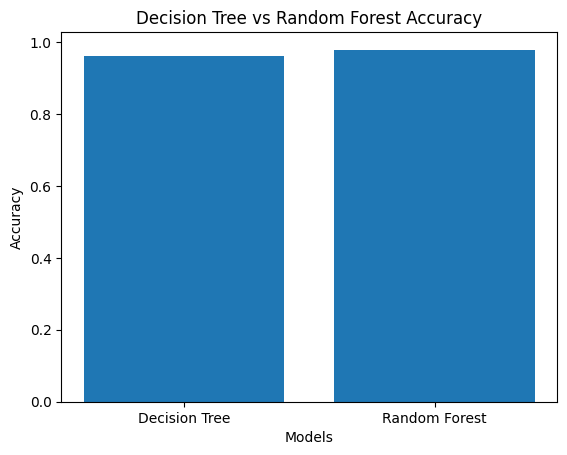

In [ ]:
import matplotlib.pyplot as plt


dt_acc = None
rf_acc = None

for name, acc in results:
    if name == "Decision Tree":
        dt_acc = acc
    elif name == "Random Forest":
        rf_acc = acc


models = ["Decision Tree", "Random Forest"]
accuracies = [dt_acc, rf_acc]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Decision Tree vs Random Forest Accuracy")
plt.show()

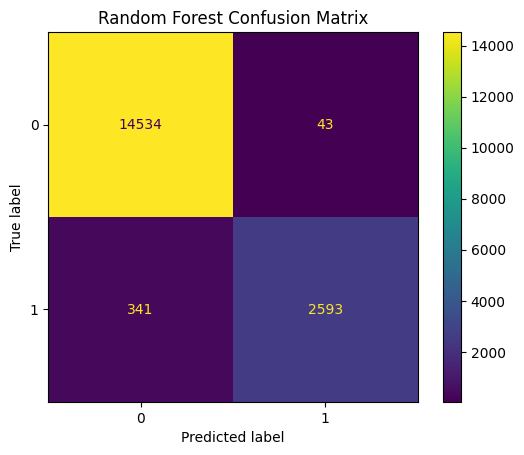

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
rf = RandomForestClassifier()
dt = DecisionTreeClassifier()

rf.fit(X_train, y_train)
dt.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_prob_dt = dt.predict_proba(X_test)[:, 1]

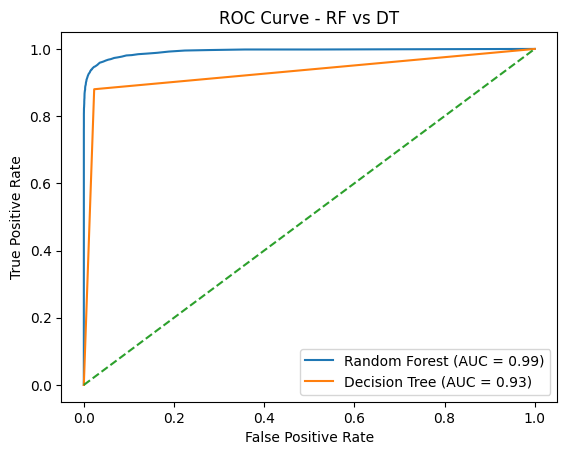

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)


auc_rf = auc(fpr_rf, tpr_rf)
auc_dt = auc(fpr_dt, tpr_dt)


plt.figure()

plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.2f})")


plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RF vs DT")
plt.legend()

plt.show()